# Sign Language Recognition - Full Machine Learning Pipeline
This notebook contains the complete implementation for training, evaluating, and saving four Machine Learning models for sign language landmark classification.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import time

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## 2. Load and Prepare Dataset

In [2]:
# Path to the folder that contains train.csv, val.csv, test.csv, and label_mapping.json
# (the files produced by preprocessing.ipynb)
DATA_DIR = r'D:\project\project_codolearn_final'

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_xyz.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val_xyz.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test_xyz.csv'))

# Features / labels (the 'label' column already holds the ENCODED numeric class,
# produced by the LabelEncoder step in preprocessing.ipynb)
X_train, y_train = train_df.drop('label', axis=1), train_df['label']
X_val,   y_val   = val_df.drop('label', axis=1),   val_df['label']
X_test,  y_test  = test_df.drop('label', axis=1),  test_df['label']

# Load the label mapping (class name -> encoded number) to show real class names later
with open(os.path.join(DATA_DIR, 'label_mapping_xyz.json'), encoding='utf-8') as f:
    label_mapping = json.load(f)

# Reverse mapping: encoded number -> class name, ordered by encoded value
inv_label_mapping = {v: k for k, v in label_mapping.items()}
class_names = [inv_label_mapping[i] for i in sorted(inv_label_mapping)]

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples: {len(X_test)}")
print(f"Number of classes: {len(class_names)}")


Training samples: 2076
Validation samples: 445
Testing samples: 445
Number of classes: 36


## 3. Hyperparameter Tuning (GridSearchCV) and Training
For each of the 4 models we run `GridSearchCV` over a small parameter grid using 3-fold cross-validation
on the **training set only** (`X_train`, `y_train`). The best estimator found for each model is then
evaluated once on the untouched **test set** (`X_test`, `y_test`).

This will take a few minutes (SVM and XGBoost grids are the slowest).

In [3]:
# Parameter grids for each model
param_grids = {
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.05, 0.1, 0.2],
    },
}

# Base (untuned) estimators
base_models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
}

results = {}          # model name -> test accuracy of the tuned model
best_params = {}       # model name -> best hyperparameters found
best_estimators = {}   # model name -> fitted best estimator

if not os.path.exists('models'):
    os.makedirs('models')

for name, model in base_models.items():
    print(f"--- Grid searching {name} ---")
    start = time.time()

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
        verbose=1,
    )
    grid.fit(X_train, y_train)

    elapsed = time.time() - start
    best_model = grid.best_estimator_

    # Evaluate the tuned model once on the untouched test set
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc
    best_params[name] = grid.best_params_
    best_estimators[name] = best_model

    model_path = f"models/{name.lower().replace(' ', '_')}_xyz_model.joblib"
    joblib.dump(best_model, model_path)

    print(f"{name} best params: {grid.best_params_}")
    print(f"{name} Test Accuracy: {acc:.4f}  (grid search took {elapsed:.1f}s)")
    print(f"Model saved to: {model_path}\n")


--- Grid searching KNN ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
KNN best params: {'n_neighbors': 3, 'weights': 'distance'}
KNN Test Accuracy: 0.9461  (grid search took 60.1s)
Model saved to: models/knn_xyz_model.joblib

--- Grid searching Random Forest ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Random Forest best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest Test Accuracy: 0.9438  (grid search took 119.3s)
Model saved to: models/random_forest_xyz_model.joblib

--- Grid searching SVM ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
SVM best params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
SVM Test Accuracy: 0.9528  (grid search took 11.0s)
Model saved to: models/svm_xyz_model.joblib

--- Grid searching XGBoost ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits
XGBoost best params: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200}
XGBoost Test Accuracy: 0.9

## 4. Final Comparison and Visualization

C:\Users\saram\AppData\Local\Temp\ipykernel_4204\2586769463.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='magma')


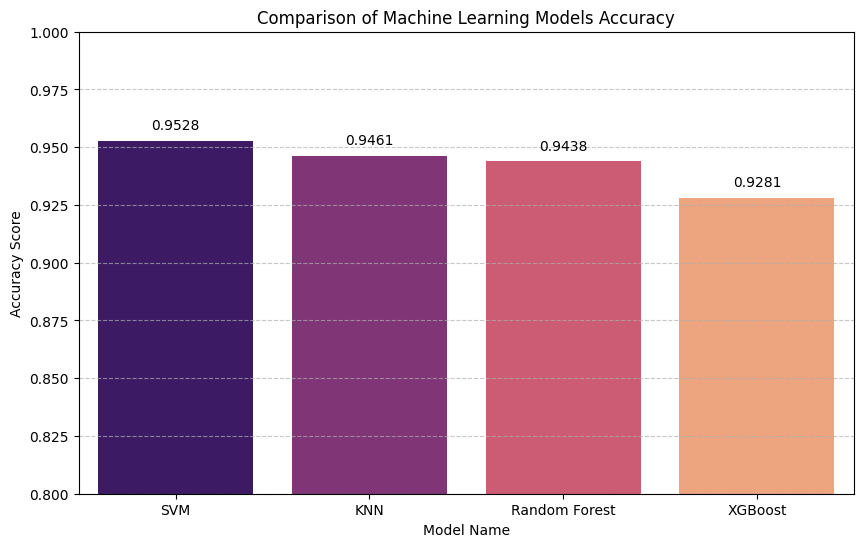

Final Comparison Table:


,Model,Accuracy
2,SVM,0.952809
0,KNN,0.946067
1,Random Forest,0.943820
3,XGBoost,0.928090


In [4]:
# Convert results to DataFrame for visualization
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='magma')
plt.ylim(0.8, 1.0)
plt.title('Comparison of Machine Learning Models Accuracy')
plt.ylabel('Accuracy Score')
plt.xlabel('Model Name')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add accuracy labels on top of bars
for index, row in comparison_df.iterrows():
    plt.text(comparison_df.index.get_loc(index), row.Accuracy + 0.005, f'{row.Accuracy:.4f}', ha='center')

plt.show()

print("Final Comparison Table:")
display(comparison_df)

## 5. Detailed Evaluation of the Best Model (Confusion Matrix)

Best model: SVM
Best hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

Classification report - SVM

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       1.00      1.00      1.00        10
           2       1.00      0.75      0.86         8
           3       1.00      1.00      1.00        10
           4       0.90      0.90      0.90        10
           5       0.91      0.91      0.91        11
           6       0.70      0.78      0.74         9
           7       1.00      1.00      1.00        10
           8       1.00      0.90      0.95        10
           9       1.00      1.00      1.00        10
           A       1.00      1.00      1.00        11
           B       1.00      1.00      1.00        16
           C       1.00      0.93      0.96        14
           D       1.00      1.00      1.00        17
           E       1.00      1.00      1.00        12
           F       

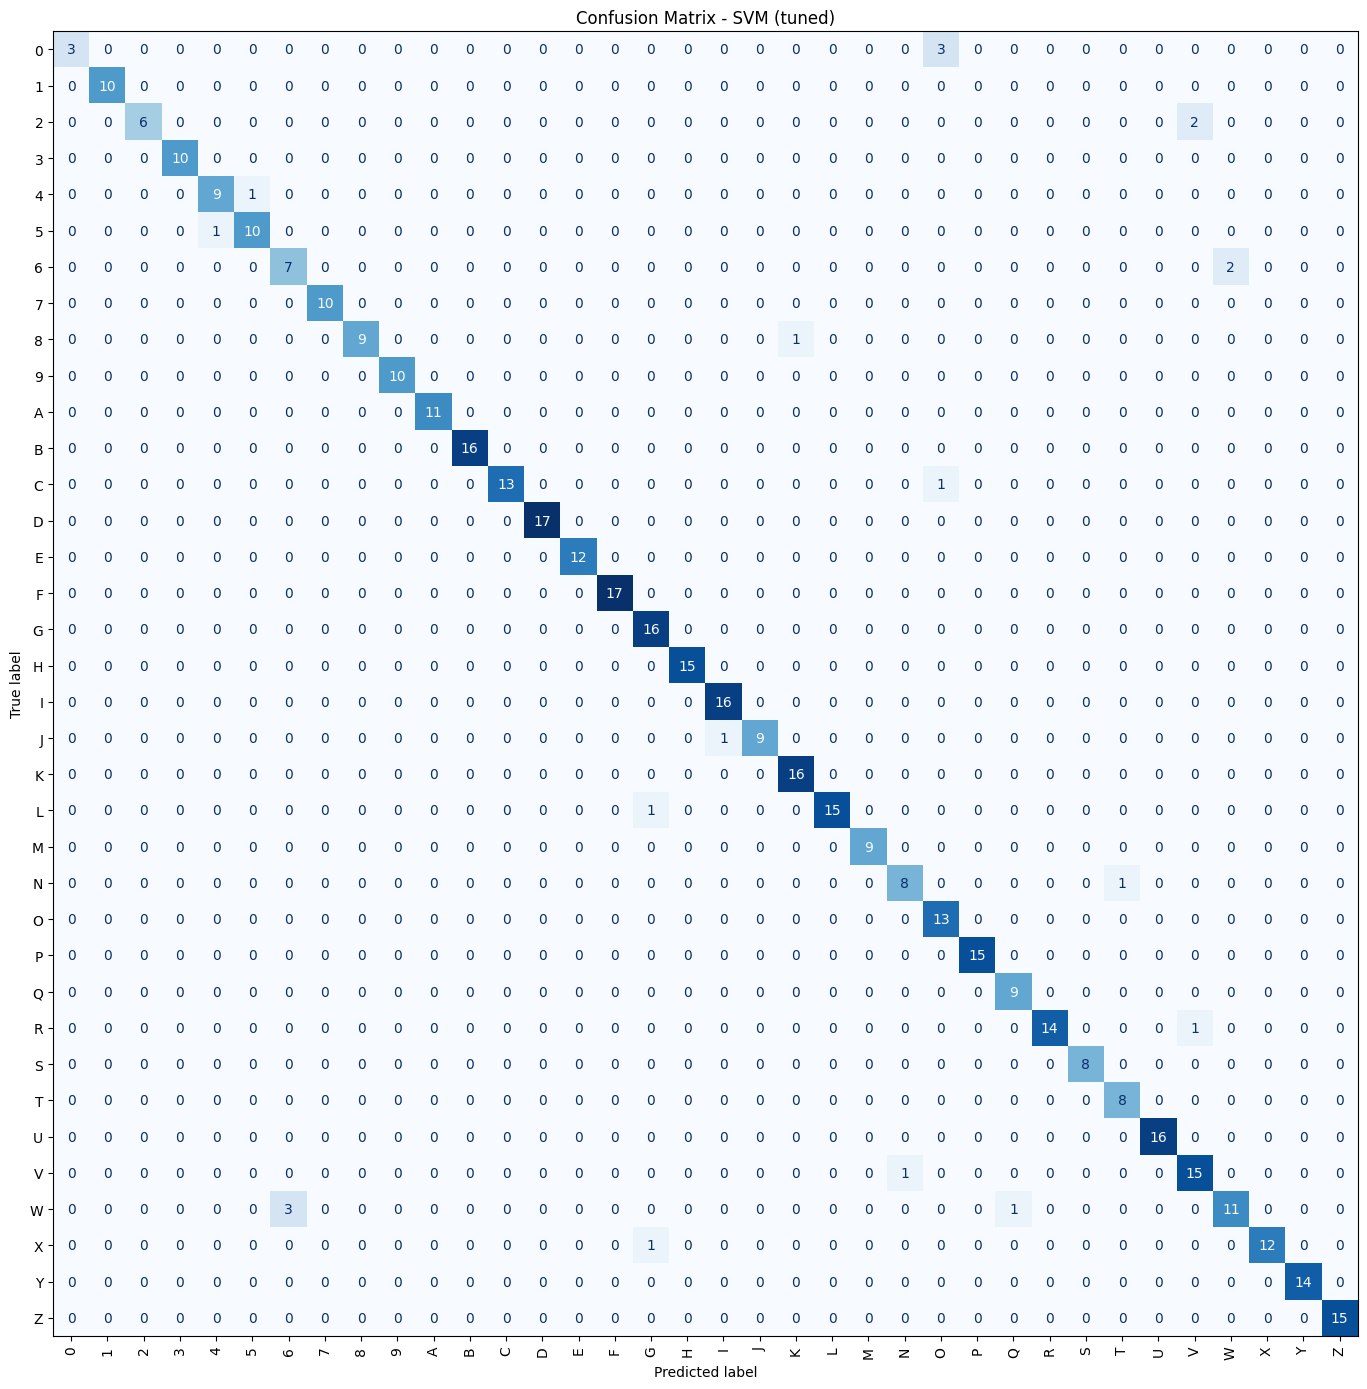

In [5]:
# Detailed report for the best (tuned) model on the TEST set
best_model_name = comparison_df.iloc[0]['Model']
best_model_path = f"models/{best_model_name.lower().replace(' ', '_')}_xyz_model.joblib"
best_model = best_estimators[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Best hyperparameters: {best_params[best_model_name]}\n")

y_pred_best = best_model.predict(X_test)

print(f"Classification report - {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation='vertical', colorbar=False, cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name} (tuned)')
plt.tight_layout()
plt.show()


## 5b. Improving Accuracy Using Only (x, y) — No New Features
Per instructions, we keep the feature set exactly as-is (normalized x, y coordinates only — 42 columns).
To push accuracy toward 95%+ without adding any new feature types, we use two techniques:

1. **Data Augmentation** (now done in `preprocessing.ipynb`) — the training set was expanded with
   small rotations of each hand's landmarks around the wrist (still just x, y values, no new feature
   types). We simply load the already-augmented `train_augmented.csv` here.
2. **Soft Voting Ensemble** — combine the 4 already-tuned models (KNN, Random Forest, SVM, XGBoost) into
   a single ensemble that averages their predicted probabilities.

### Load the Augmented Training Set
Produced by `preprocessing.ipynb` (Section 8) — small rotations applied to the training set only.

In [6]:
train_aug_df = pd.read_csv(os.path.join(DATA_DIR, 'train_augmented_xyz.csv'))

X_train_aug = train_aug_df.drop('label', axis=1)
y_train_aug = train_aug_df['label']

print(f"Original training samples: {len(X_train)}")
print(f"Augmented training samples: {len(X_train_aug)}")


Original training samples: 2076
Augmented training samples: 14532


### Retrain All 4 Models on the Augmented Data

In [7]:
augmented_models = {
    "KNN": KNeighborsClassifier(**best_params["KNN"]),
    "Random Forest": RandomForestClassifier(random_state=42, **best_params["Random Forest"]),
    "SVM": SVC(probability=True, random_state=42, **best_params["SVM"]),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42, **best_params["XGBoost"]),
}

augmented_results = {}
augmented_estimators = {}

for name, model in augmented_models.items():
    model.fit(X_train_aug, y_train_aug)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    augmented_results[name] = acc
    augmented_estimators[name] = model
    print(f"{name} (augmented, x-y only) Test Accuracy: {acc:.4f}")


KNN (augmented, x-y only) Test Accuracy: 0.9551
Random Forest (augmented, x-y only) Test Accuracy: 0.9281
SVM (augmented, x-y only) Test Accuracy: 0.9551
XGBoost (augmented, x-y only) Test Accuracy: 0.9326


### Soft Voting Ensemble — Combine All 4 Tuned Models

In [8]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("knn", augmented_models["KNN"]),
        ("rf", augmented_models["Random Forest"]),
        ("svm", augmented_models["SVM"]),
        ("xgb", augmented_models["XGBoost"]),
    ],
    voting="soft",   # average predicted probabilities instead of a hard majority vote
)

voting_clf.fit(X_train_aug, y_train_aug)
y_pred_vote = voting_clf.predict(X_test)
voting_acc = accuracy_score(y_test, y_pred_vote)

print(f"Voting Ensemble (KNN + RF + SVM + XGBoost) Test Accuracy: {voting_acc:.4f}")

if not os.path.exists('models'):
    os.makedirs('models')
joblib.dump(voting_clf, "models/voting_ensemble_xyz_model.joblib")
print("Saved to models/voting_ensemble_xyz_model.joblib")


Voting Ensemble (KNN + RF + SVM + XGBoost) Test Accuracy: 0.9708
Saved to models/voting_ensemble_xyz_model.joblib


### Summary — Raw vs Augmented vs Ensemble (x, y only, no engineered features)

,Model,"Raw (x,y) Accuracy","Augmented (x,y) Accuracy"
0,KNN,0.946067,0.955056
1,Random Forest,0.943820,0.928090
2,SVM,0.952809,0.955056
3,XGBoost,0.928090,0.932584
4,Voting Ensemble,NaN,0.970787


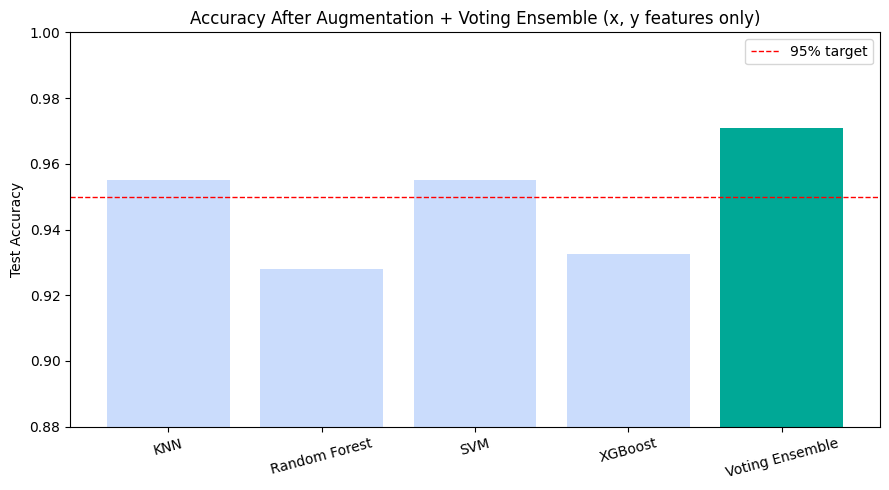

In [9]:
summary_xy = pd.DataFrame({
    "Model": list(results.keys()) + ["Voting Ensemble"],
    "Raw (x,y) Accuracy": list(results.values()) + [None],
    "Augmented (x,y) Accuracy": [augmented_results.get(m) for m in results.keys()] + [voting_acc],
})
display(summary_xy)

plt.figure(figsize=(9, 5))
x_pos = np.arange(len(summary_xy))
plt.bar(x_pos, summary_xy["Augmented (x,y) Accuracy"], color=["#CADCFC"]*4 + ["#00A896"])
plt.axhline(0.95, color="red", linestyle="--", linewidth=1, label="95% target")
plt.xticks(x_pos, summary_xy["Model"], rotation=15)
plt.ylabel("Test Accuracy")
plt.ylim(0.88, 1.0)
plt.legend()
plt.title("Accuracy After Augmentation + Voting Ensemble (x, y features only)")
plt.tight_layout()
plt.show()


## 6. Feature Importance - Random Forest & XGBoost
Both models expose `.feature_importances_` after training. This tells us which of the 42 landmark
coordinates (x0,y0 ... x20,y20) actually matter for classification, and which ones are close to useless
(we already expect x0,y0 to be near-zero importance, since they're always 0 after normalization).

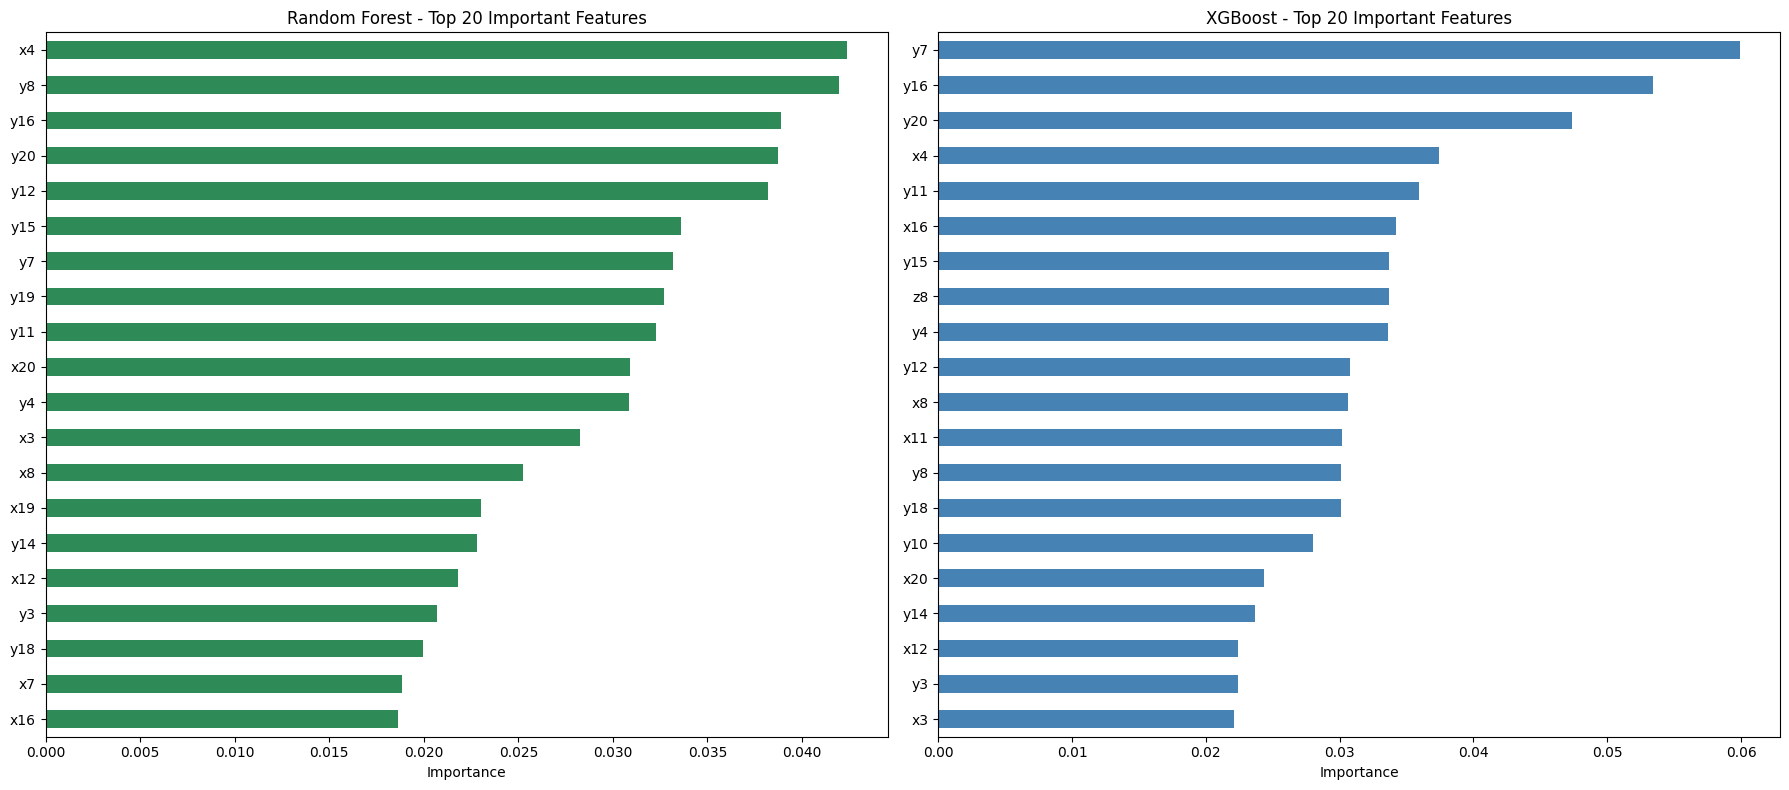

Random Forest - Bottom 10 (least important) features:
z7     0.005873
z14    0.005692
z6     0.005673
z8     0.005582
z12    0.005390
z10    0.004836
z11    0.004816
z0     0.000000
x0     0.000000
y0     0.000000
dtype: float64

XGBoost - Bottom 10 (least important) features:
z3     0.004439
z4     0.003625
z7     0.003595
z11    0.003183
z13    0.002490
z9     0.002211
z10    0.002058
z0     0.000000
x0     0.000000
y0     0.000000
dtype: float32


In [10]:
rf_model = best_estimators["Random Forest"]
xgb_model = best_estimators["XGBoost"]

feature_names = X_train.columns

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

rf_importance.head(20).plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].invert_yaxis()
axes[0].set_title('Random Forest - Top 20 Important Features')
axes[0].set_xlabel('Importance')

xgb_importance.head(20).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('XGBoost - Top 20 Important Features')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("Random Forest - Bottom 10 (least important) features:")
print(rf_importance.tail(10))
print("\nXGBoost - Bottom 10 (least important) features:")
print(xgb_importance.tail(10))


## 7. Confusion Matrix Comparison - Random Forest vs XGBoost
Side-by-side confusion matrices so we can spot which classes each model confuses,
and whether the two models make similar or different mistakes.

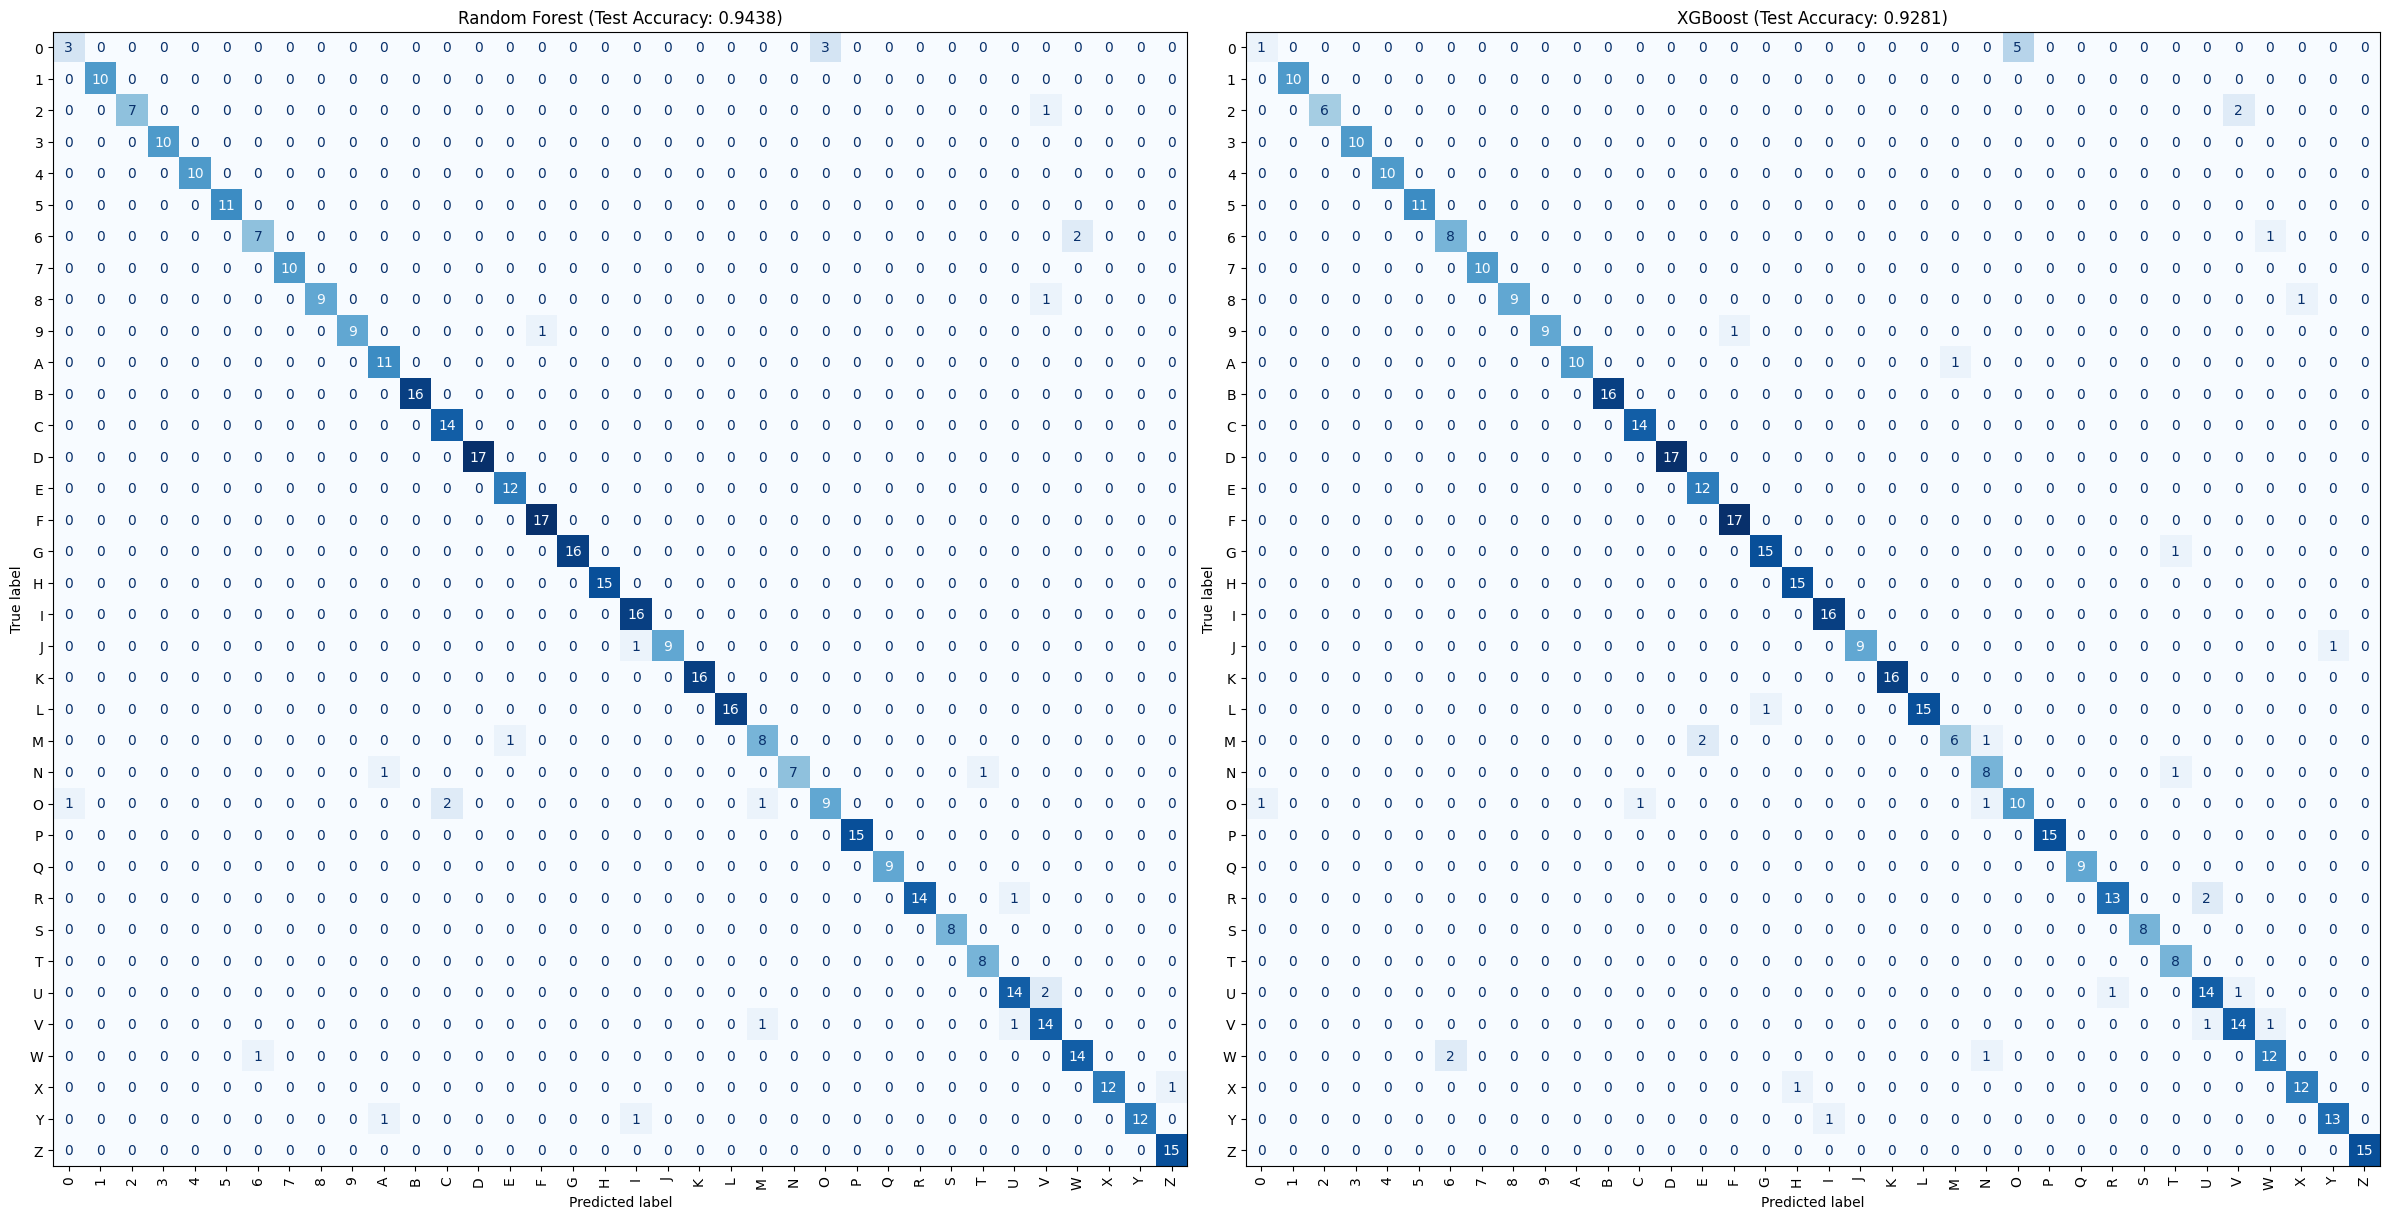

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

for ax, (name, model) in zip(axes, [("Random Forest", rf_model), ("XGBoost", xgb_model)]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation='vertical', colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name} (Test Accuracy: {acc:.4f})')

plt.tight_layout()
plt.show()


In [12]:
# Which classes get confused the most, per model? (top mistaken pairs)
def top_confusions(model, name, top_n=10):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    mistakes = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                mistakes.append((class_names[i], class_names[j], cm[i, j]))
    mistakes.sort(key=lambda x: x[2], reverse=True)
    print(f"--- {name}: Top confused pairs (true -> predicted : count) ---")
    for true_label, pred_label, count in mistakes[:top_n]:
        print(f"  {true_label} -> {pred_label} : {count}")
    print()

top_confusions(rf_model, "Random Forest")
top_confusions(xgb_model, "XGBoost")


--- Random Forest: Top confused pairs (true -> predicted : count) ---
  0 -> O : 3
  6 -> W : 2
  O -> C : 2
  U -> V : 2
  2 -> V : 1
  8 -> V : 1
  9 -> F : 1
  J -> I : 1
  M -> E : 1
  N -> A : 1

--- XGBoost: Top confused pairs (true -> predicted : count) ---
  0 -> O : 5
  2 -> V : 2
  M -> E : 2
  R -> U : 2
  W -> 6 : 2
  6 -> W : 1
  8 -> X : 1
  9 -> F : 1
  A -> M : 1
  G -> T : 1



## 8. Loading a Model (Without Retraining)
To use the models later without running the training code above, use this block:

In [13]:
# Example: Load the best model (whichever one won, saved by name above)
final_model = joblib.load(best_model_path)
print(f"Model loaded successfully: {best_model_name}")

# Predict on new normalized landmark data (42 features: x0,y0 ... x20,y20)
# new_data should be a DataFrame with the SAME columns/order as X_train
# pred_encoded = final_model.predict(new_data)
# pred_label = inv_label_mapping[pred_encoded[0]]


Model loaded successfully: SVM
